Read ME! 
To run this code, press "run all" on the very top of the notebook. This should output 3 different cases demonstrating 3 different types of arrival rates tested on the system. Please make sure that if you'r not running on a mac, change the row in codeblock 2 as stated, namely "# Set the quantization engine. Use 'qnnpack' for Mac, or 'fbgemm' for Windows/Intel
torch.backends.quantized.engine = 'qnnpack'"

Lets start by importing MNIST and setting up a simple le-net CNN model

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchinfo import summary
import random
import numpy as np


def set_seed(seed=42): #set seed so that results are reproducable
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# grab the MNIST dataset. using standard normalizations from the pytorch docs
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# download train/test sets to a local 'data' folder
tr_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
te_data = datasets.MNIST('./data', train=False, transform=transform)

# data 
train_loader = DataLoader(tr_data, batch_size=64, shuffle=True)
test_loader = DataLoader(te_data, batch_size=1000, shuffle=False)

# Baseline model 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1) #using log_softmax to get probabilities since we use nll_loss later
        return output

# init the baseline model
baseline_model = Net()

#train the model
def train_model(model, train_loader, epochs=1):
    # Adadelta like the github
    optimizer = optim.Adadelta(model.parameters(), lr=1.0)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.7)
    
    model.train() #set it to training mode
    
    #training loop. just doing 1 epoch here so we don't wait for long during testing
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad() # zero the parameter gradients
            output = model(data) # forward pass the log probabilities
            loss = F.nll_loss(output, target) #computes loss
            loss.backward() # backpropagate the loss
            optimizer.step() #parameter update
        scheduler.step() # update the learning rate
    print("Done training!")

#let's run it
train_model(baseline_model, train_loader, epochs=1)




Done training!


For analysis and to meet the requirments for this assignment, I will implemet 2 versions of this baseline model. One which is pruned, and one which is a quantized model. Both these models will trade som accuracy for computation. 

In [2]:
import copy
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.ao.quantization


# model Compression 

# pruned model

pruned_model = copy.deepcopy(baseline_model) #copy of baseline model

#looping over layers and applying structured pruning to conv layers. (simulates channel pruning as in lec 5)
for name, module in pruned_model.named_modules():
    if isinstance(module, nn.Conv2d):
        #removes 30% of entire filters (dim=0) using L2 norm (n=2)
        prune.ln_structured(module, name='weight', amount=0.3, n=2, dim=0)
        # actually remove the pruned weights from the model (makes them truly zero and non-trainable)
        prune.remove(module, 'weight')
    elif isinstance(module, nn.Linear):
        # For linear layers, we can do unstructured pruning (removing individual weights) to further reduce size
        prune.l1_unstructured(module, name='weight', amount=0.3) # remove 30% of individual weights
        prune.remove(module, 'weight')

# quantized model 
model_to_quantize = copy.deepcopy(baseline_model) #copy baseline again

# Set the quantization engine. Use 'qnnpack' for Mac, or 'fbgemm' for Windows/Intel
torch.backends.quantized.engine = 'qnnpack'

#  quantization, converts float32 weights to int8 for linear layers.
quantized_model = torch.ao.quantization.quantize_dynamic(
    model_to_quantize,  
    {nn.Linear},        
    dtype=torch.qint8   
) #this reduces memory as taught in LEC04.


baseline_model.eval()
pruned_model.eval()
quantized_model.eval()
# Save them to a dictionary
ai_models = {
    "baseline": baseline_model,
    "pruned": pruned_model,
    "quantized": quantized_model
}

print("Done! We now have 3 models ready for our AIoT Simulator.")

Done! We now have 3 models ready for our AIoT Simulator.


Queue: 
To evaluate the AIoT system under constraints, we need to simulate the hardware and network environment. This section defines the system sarameters (like simulated compute times for Edge vs. Cloud and network latency). 

It also implements the queue and the admission control policy. When the data arrival rate exceeds working capacity, the queue will fill up. If it hits the max capacity, the admission controller will drop the newest incoming sample (drop_new) or the oldest sample currently waiting in the queue (drop_old) based on the setting from the user. 

In [3]:
import time
from collections import deque


# System Parameter Simulation

parameters = {
    'queue_size': 10,         # max data samples allowed in the queue
    'deadline_ms': 100,            # deadline
    'network_latency_ms': 20,      # network delay
    
    'compute_times': {
        'edge': {'baseline': 40, 'pruned': 25, 'quantized': 20}, #made up numbers to reflect that pruned and quantized models should be faster
        'cloud': {'baseline': 5, 'pruned': 3, 'quantized': 2} #same here
    }
}

class DataSample: #define datasamples with its params
    def __init__(self, sid, data, target, generation_time):
        self.sid = sid #sample id
        self.data = data #the actual data (image tensor)
        self.target = target #label
        sensor_delay = 5 # delay to reach the device
        self.g = generation_time - sensor_delay  # Generation time
        self.a = generation_time                 # Arrival time 
        self.deadline = self.g + parameters['deadline_ms'] #deadline based on when the sample was generated

        

class ProcessingQueue: #define the queu with its params
    def __init__(self, queue_size, overflow_policy="DropOld"):
        self.queue_size = queue_size            
        self.queue = deque() 
        self.overflow_policy = overflow_policy 
        self.dropped_samples = 0 

    def enqueue(self, sample):
        
        if len(self.queue) >= self.queue_size:
            if self.overflow_policy == "DropNew": #if set to drop new, we drop dont add the new sample and count it as dropped 
                self.dropped_samples += 1
                return False
            elif self.overflow_policy == "DropOld":#same for dropold, we drop the oldest sample (first in queue)
                # Find and remove the oldest sample (first in queue)
                self.queue.popleft()
                self.queue.append(sample)
                self.dropped_samples += 1
                return True
        else:
            self.queue.append(sample) #else we just add the sample
            return True

    def dequeue(self):
        if len(self.queue) > 0:
            return self.queue.popleft()
        return None
    
    def is_empty(self):
        return len(self.queue) == 0

# Test
test_queue = ProcessingQueue(queue_size=parameters['queue_size'], overflow_policy="DropOld")

Scheduler: 
This scheduler implements "Compute Control" and "Distributed Deployment". It monitors the ProcessingQueue. 
If the queue is small, it runs the baseline model on the edge for maximum accuracy. 
As the queue fills up (risk of missing the 100ms deadline), it adapts by either switching to a lighter model or sending the data to the cloud.

In [4]:

class AIScheduler:
    def __init__(self, system_params):
        self.params = system_params

    def make_decision(self, queue_length):
        max_queue_size = self.params['queue_size']
        occupancy_ratio = queue_length / max_queue_size #how full is the queue?
        
        # if low traffic run abseline for high accucracy
        if occupancy_ratio < 0.3:
            model_name = 'baseline'
            location = 'edge'
            
        # if medium traffic, prune to save computation with ok accuracy
        elif occupancy_ratio < 0.6:
            model_name = 'pruned'
            location = 'edge'
        
        #if high traffic, quantize to save memory, should punish accuracy
        elif occupancy_ratio < 0.85:
            model_name = 'quantized'
            location = 'edge'
            
        #overload, send to cloud with a higher speed, comes with the cost of network latancy
        else:
            model_name = 'pruned' #use pruned to reduce latency even more
            location = 'cloud'
            
        #fetch comp time
        compute_time = self.params['compute_times'][location][model_name]
        
        # add the latency for cloud
        if location == 'cloud':
            compute_time += self.params['network_latency_ms']
            
        return model_name, location, compute_time



Simuation: 
Here I run the actual simulation over time. The arrivalrate can be changed to simulate different loadings.

During the simulation, the system processes real MNIST images and we track:
End-to-end latency: Both the average and the 99th percentile (Tail Latency).
Data Freshness (AoI): How old the image is when the final decision is ready.
Queue behavior: How the queue fills up and how many stale samples are dropped.
Accuracy & Model Switching: Whether the prediction was correct, and which model/location the scheduler chose for that specific image and how well each model performed when it was used.

The function then prints a summary of the metrics and plots the results.

To run the DropNew model as demonstrated in results, simply change overflow_policy="DropOld" to overflow_policy="DropNew"

Results
Processed: 400 | Dropped (DropOld): 0
Missed deadlines: 0
Accuracy: 98.2%
Avg Latency:   40.0 ms | Tail Latency (99%):   40.0 ms
Avg Freshness: 45.0 ms | Tail Freshness (99%): 45.0 ms
Model: baseline_edge | Used: 100.0% of the time | Avg Latency: 40.0 ms | Accuracy: 98.2%


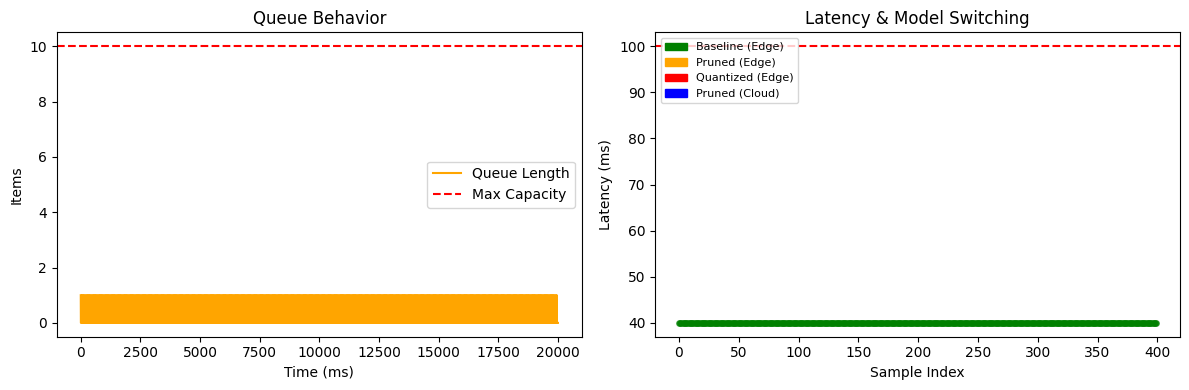

Results
Processed: 790 | Dropped (DropOld): 0
Missed deadlines: 990
Accuracy: 97.7%
Avg Latency:   109.7 ms | Tail Latency (99%):   119.0 ms
Avg Freshness: 114.7 ms | Tail Freshness (99%): 124.0 ms
Model: baseline_edge | Used: 0.4% of the time | Avg Latency: 60.0 ms | Accuracy: 100.0%
Model: pruned_edge | Used: 99.6% of the time | Avg Latency: 109.9 ms | Accuracy: 97.7%


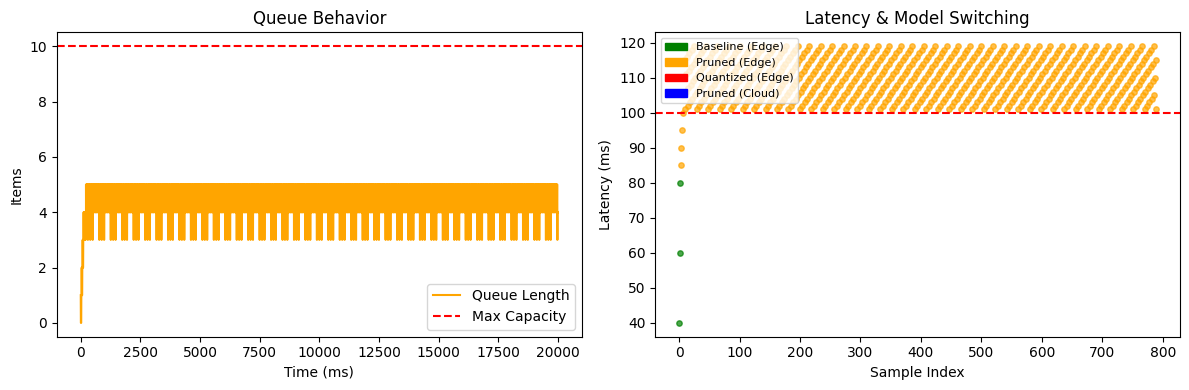

[W416 13:29:25.083503000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


Results
Processed: 869 | Dropped (DropOld): 2121
Missed deadlines: 0
Accuracy: 97.1%
Avg Latency:   85.7 ms | Tail Latency (99%):   89.0 ms
Avg Freshness: 90.7 ms | Tail Freshness (99%): 94.0 ms
Model: quantized_edge | Used: 0.1% of the time | Avg Latency: 71.0 ms | Accuracy: 100.0%
Model: pruned_cloud | Used: 99.7% of the time | Avg Latency: 85.8 ms | Accuracy: 97.1%
Model: baseline_edge | Used: 0.1% of the time | Avg Latency: 40.0 ms | Accuracy: 100.0%
Model: pruned_edge | Used: 0.1% of the time | Avg Latency: 58.0 ms | Accuracy: 100.0%


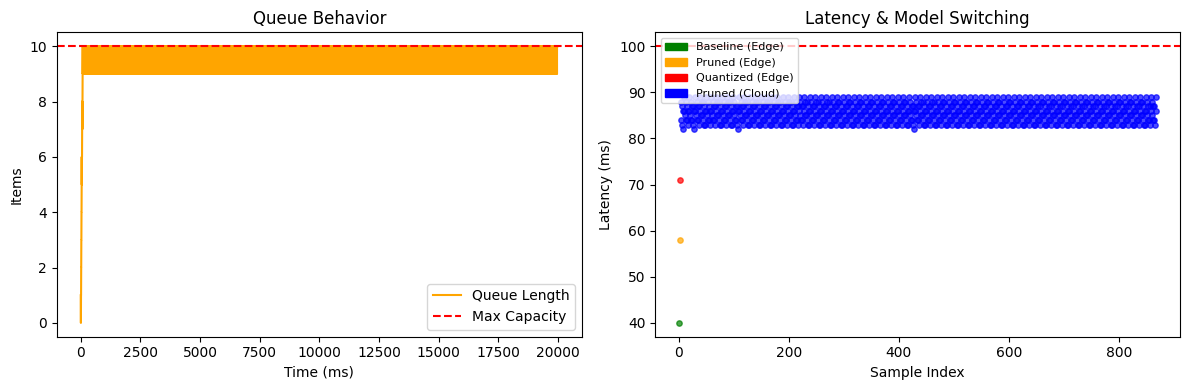

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def get_more_data(loader): #data generator function
    while True:
        for data, target in loader: #get data and label
            for i in range(data.size(0)):  #loop over it 
                yield data[i].unsqueeze(0), target[i].item() #use one sample at a time


def simulate_results(models, test_loader, fps=40, sim_time=20000):
    data_stream = get_more_data(test_loader) #fetch data 
    queue = ProcessingQueue(queue_size=parameters['queue_size'], overflow_policy="DropOld") #init the queue
    scheduler = AIScheduler(parameters) #init the scheduler
    
    ms_per_frame = 1000.0 / fps
    next_arrival = 0
    busy_until = 0
    
    #just to store data later
    latencies, freshnesses, queue_sizes, accuracies, choices = [], [], [], [], []
    missed_deadlines = 0
    
    #loop through the simulation time
    for t in range(sim_time): 
        
        # data generation
        if t >= next_arrival: #generate new sample if its time
            img, label = next(data_stream) #fetch the sample 
            sample = DataSample(sid=0, data=img, target=label, generation_time=t) #
            queue.enqueue(sample) #add it
            next_arrival += ms_per_frame #schedule next arrival
            
        queue_sizes.append(len(queue.queue)) #add size of queue to list
        
        # Processa data
        if t >= busy_until and not queue.is_empty(): #if we are not busy and there is data to process
            sample = queue.dequeue() #get the sample to process

            if (t - sample.g) >= parameters['deadline_ms']: #drop stale data
                missed_deadlines += 1  #count it as a missed deadline if the sample is already too old when we start processing it and we skip it
                continue
            m_name, loc, cost = scheduler.make_decision(len(queue.queue))
            
            # Inference
            with torch.no_grad(): 
                pred = models[m_name](sample.data).argmax(dim=1).item() #store prediction
            
            accuracies.append(1 if pred == sample.target else 0) # store accuracy for this sample
            choices.append(f"{m_name}_{loc}") #store model choice
            
            # times and freshness
            busy_until = t + cost
            
            # 1. Latency (Time from data arrival to decision output)
            lat = busy_until - sample.a #time from arrival to prediction
            latencies.append(lat)
            
            # 2. Freshness (how old the data is when the decision is produced)
            fresh = busy_until - sample.g # time generation to prediction
            freshnesses.append(fresh)
            
            if busy_until > sample.deadline:
                missed_deadlines += 1

    # 2. calculate results
    avg_lat = sum(latencies) / len(latencies)
    sorted_lats = sorted(latencies)
    tail_lat = sorted_lats[int(len(sorted_lats) * 0.99)] # 99th percentile
    
    
    avg_fresh = sum(freshnesses) / len(freshnesses)
    sorted_fresh = sorted(freshnesses)
    tail_fresh = sorted_fresh[int(len(sorted_fresh) * 0.99)] # 99th percentile
    
    acc_pct = (sum(accuracies) / len(accuracies)) * 100
    
    print("Results")
    print(f"Processed: {len(latencies)} | Dropped (DropOld): {queue.dropped_samples}")
    print(f"Missed deadlines: {missed_deadlines}")
    print(f"Accuracy: {acc_pct:.1f}%")
    print(f"Avg Latency:   {avg_lat:.1f} ms | Tail Latency (99%):   {tail_lat:.1f} ms")
    print(f"Avg Freshness: {avg_fresh:.1f} ms | Tail Freshness (99%): {tail_fresh:.1f} ms")

    used_models = set(choices) #se what models were used
    
    for model in used_models: #check each model
        count = 0
        total_lat = 0
        total_acc = 0
        
        # A simple loop to collect data for this specific model
        for i in range(len(choices)):
            if choices[i] == model:
                count += 1
                total_lat += latencies[i]
                total_acc += accuracies[i]
                
        # Calculate percentages and averages for the model 
        percent_used = (count / len(choices)) * 100
        avg_model_lat = total_lat / count
        avg_model_acc = (total_acc / count) * 100
        
        print(f"Model: {model} | Used: {percent_used:.1f}% of the time | Avg Latency: {avg_model_lat:.1f} ms | Accuracy: {avg_model_acc:.1f}%")


    # 3. plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # graph 1: queue 
    ax1.plot(queue_sizes, color="orange", label="Queue Length")
    ax1.axhline(parameters['queue_size'], color="red", linestyle="--", label="Max Capacity")
    ax1.set(title="Queue Behavior", xlabel="Time (ms)", ylabel="Items")
    ax1.legend()

    # graph 2: Freshness & models
    color_map = {'baseline_edge': 'green', 'pruned_edge': 'orange', 'quantized_edge': 'red', 'baseline_cloud': 'blue', 'pruned_cloud': 'blue'}
    
    for i, choice in enumerate(choices):
        ax2.scatter(i, latencies[i], color=color_map.get(choice, 'black'), s=15, alpha=0.7)
        
    ax2.axhline(parameters['deadline_ms'], color="red", linestyle="--", label="Deadline (100ms)")
    ax2.set(title="Latency & Model Switching", xlabel="Sample Index", ylabel="Latency (ms)")
    
    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(
        ['green', 'orange', 'red', 'blue'], 
        ['Baseline (Edge)', 'Pruned (Edge)', 'Quantized (Edge)', 'Pruned (Cloud)'])]
        
    ax2.legend(handles=handles, loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()

#run
simulate_results(ai_models, test_loader, fps=20)
simulate_results(ai_models, test_loader, fps=50)
simulate_results(ai_models, test_loader, fps=150)

In [6]:

# odel metrics (#MACs)

for model_name, model in ai_models.items():
    print(f"\nProfiling: {model_name.upper()} MODEL")
    
    #use torchinfo to get the number of params and MACS
    stats = summary(
        model, 
        input_size=(1, 1, 28, 28), 
        col_names=["num_params", "mult_adds"], 
        verbose=0
    )
    
    print(f"Total Parameters: {stats.total_params:,}")
    print(f"Total Mult-Adds (MACs): {stats.total_mult_adds:,}")
    





Profiling: BASELINE MODEL
Total Parameters: 1,199,882
Total Mult-Adds (MACs): 12,051,082

Profiling: PRUNED MODEL
Total Parameters: 1,199,882
Total Mult-Adds (MACs): 12,051,082

Profiling: QUANTIZED MODEL
Total Parameters: 18,816
Total Mult-Adds (MACs): 10,870,016
